In [57]:
# Superstore Sales Analysis
#Goal:** Analyze a retail store dataset to understand sales, top products, profit, and trends over time.
#Tools:** Python, pandas, matplotlib, seaborn, Jupyter Notebook
import pandas as pd

In [14]:
df = pd.read_csv("../data/SampleSuperstore.csv",encoding="latin1")
df.head()



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
df.shape

(9994, 21)

In [18]:
# now we start EDA — Exploratory Data Analysis
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [19]:
df.shape

(9994, 21)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [21]:
#How many times was each product category sold?
df["Category"].value_counts()

Office Supplies    6026
Furniture          2121
Technology         1847
Name: Category, dtype: int64

In [23]:
#Total sales per product category
df.groupby("Category")["Sales"].sum()
# Note Although office supplies are in higher demand, technology may generate higher sales.This is a true insight in sales analysis.

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

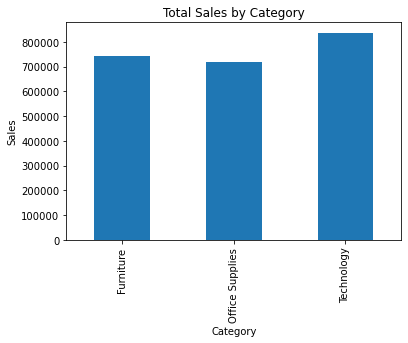

In [24]:
# Draw the first Visualization
import matplotlib.pyplot as plt

sales_by_category = df.groupby("Category")["Sales"].sum()

sales_by_category.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()
# this is first #EDA Visualization

In [25]:
#Which Sub-Category achieved the highest sales?
df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

In [34]:
#Converting dates from text to numbers
df["Order Date"] = pd.to_datetime(df["Order Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [39]:
# now Time Series Analysis
#first Create a column for month and year
df["YearMonth"] = df["Order Date"].dt.to_period("M")
#Collect sales monthly
monthly_sales = df.groupby("YearMonth")["Sales"].sum()
monthly_sales

YearMonth
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2

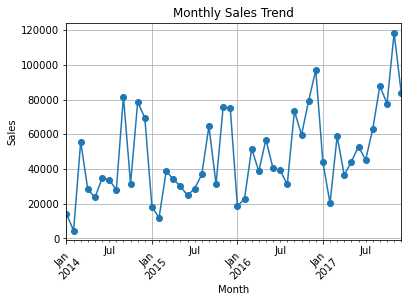

In [40]:
# drawing Monthly sales 
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [41]:
# now Sales analysis by category and time period together
category_monthly_sales = df.groupby(["YearMonth", "Category"])["Sales"].sum().unstack()
category_monthly_sales


Category,Furniture,Office Supplies,Technology
YearMonth,,,
2014-01,6242.5250,4851.080,3143.290
2014-02,1839.6580,1071.724,1608.510
2014-03,14573.9560,8605.879,32511.174
2014-04,7944.8370,11155.074,9195.434
2014-05,6912.7870,7135.624,9599.876
2014-06,13206.1256,12953.037,8435.965
2014-07,10821.0510,15121.208,8004.134
2014-08,7320.3465,11379.462,9209.660
2014-09,23816.4808,27423.298,30537.572


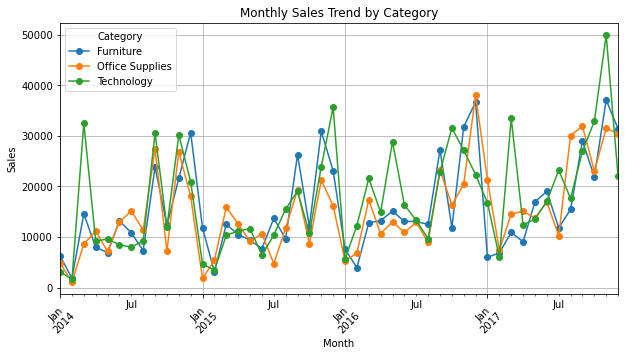

In [42]:
#Monthly sales chart for each category
category_monthly_sales.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Sales Trend by Category")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Category")
plt.show()

In [43]:
#Analysis of Sub-Category and profitability of each product with advanced graphs.
# 1️⃣ تحليل المبيعات حسب Sub-Category
subcat_sales = df.groupby(["Category", "Sub-Category"])["Sales"].sum().sort_values(ascending=False)
subcat_sales


Category         Sub-Category
Technology       Phones          330007.0540
Furniture        Chairs          328449.1030
Office Supplies  Storage         223843.6080
Furniture        Tables          206965.5320
Office Supplies  Binders         203412.7330
Technology       Machines        189238.6310
                 Accessories     167380.3180
                 Copiers         149528.0300
Furniture        Bookcases       114879.9963
Office Supplies  Appliances      107532.1610
Furniture        Furnishings      91705.1640
Office Supplies  Paper            78479.2060
                 Supplies         46673.5380
                 Art              27118.7920
                 Envelopes        16476.4020
                 Labels           12486.3120
                 Fasteners         3024.2800
Name: Sales, dtype: float64

In [44]:
#2️⃣ تحليل الربحية لكل Sub-Category

#نحسب Profit لكل Sub-Category:
subcat_profit = df.groupby(["Category", "Sub-Category"])["Profit"].sum().sort_values(ascending=False)
subcat_profit

    

Category         Sub-Category
Technology       Copiers         55617.8249
                 Phones          44515.7306
                 Accessories     41936.6357
Office Supplies  Paper           34053.5693
                 Binders         30221.7633
Furniture        Chairs          26590.1663
Office Supplies  Storage         21278.8264
                 Appliances      18138.0054
Furniture        Furnishings     13059.1436
Office Supplies  Envelopes        6964.1767
                 Art              6527.7870
                 Labels           5546.2540
Technology       Machines         3384.7569
Office Supplies  Fasteners         949.5182
                 Supplies        -1189.0995
Furniture        Bookcases       -3472.5560
                 Tables         -17725.4811
Name: Profit, dtype: float64

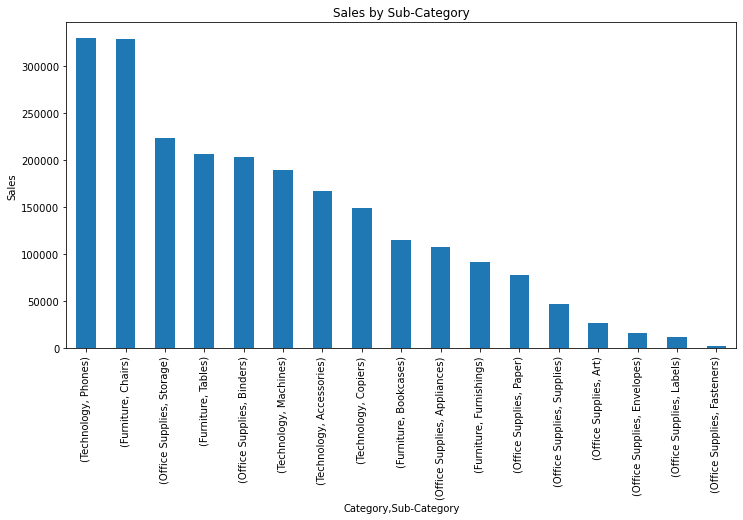

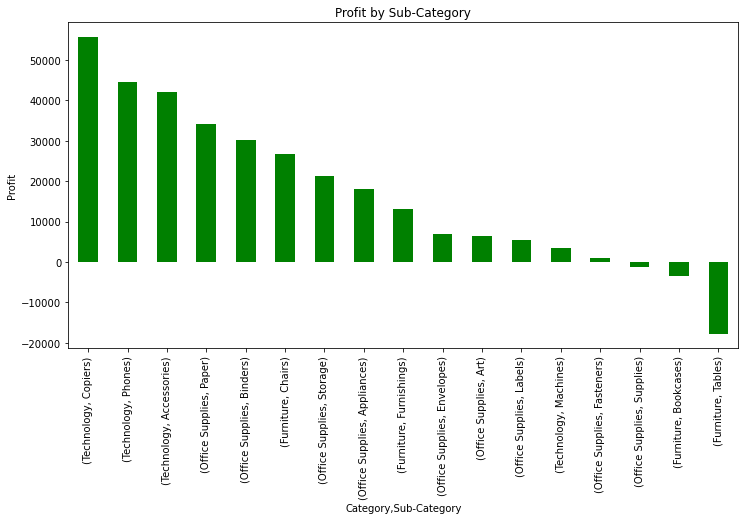

In [45]:
#3️⃣ رسم المبيعات والربحية لكل Sub-Category
# المبيعات
subcat_sales.plot(kind="bar", figsize=(12,6), title="Sales by Sub-Category")
plt.ylabel("Sales")
plt.show()

# الربحية
subcat_profit.plot(kind="bar", figsize=(12,6), title="Profit by Sub-Category", color='green')
plt.ylabel("Profit")
plt.show()

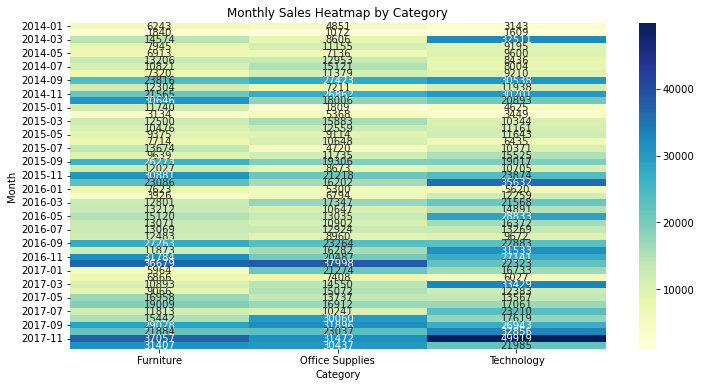

In [46]:
# 4️⃣ تحليل المبيعات والربحية حسب الفئة والزمن (Advanced)
# يمكننا عمل Heatmap لتوضيح المبيعات لكل فئة لكل شهر:
import seaborn as sns

category_monthly_sales = df.groupby(["YearMonth", "Category"])["Sales"].sum().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(category_monthly_sales, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Monthly Sales Heatmap by Category")
plt.ylabel("Month")
plt.show()


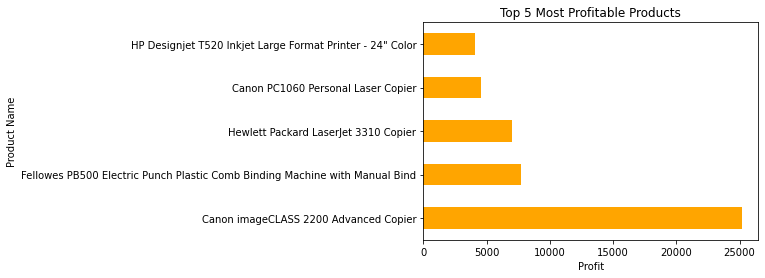

In [47]:
# 5️⃣ المرحلة المتقدمة الإضافية (اختياري لكن مهم للPortfolio)
# تحليل Top 5 Products by Profit:
top_products = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(5)
top_products.plot(kind="barh", color='orange', title="Top 5 Most Profitable Products")
plt.xlabel("Profit")
plt.show()


In [48]:
# 1️⃣ حساب Top 5 Products by Profit
top_products = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(5)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Name: Profit, dtype: float64

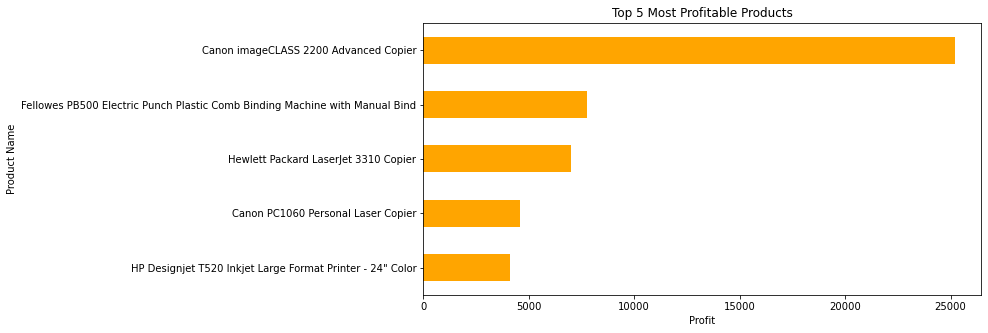

In [49]:
# 2️⃣ رسم Bar chart للـ Top 5 Products
top_products.plot(kind="barh", color='orange', figsize=(10,5), title="Top 5 Most Profitable Products")
plt.xlabel("Profit")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()  # ليظهر الأعلى ربحًا في الأعلى
plt.show()

In [50]:
# 1️⃣ تحليل الربحية لكل فئة بالنسبة لمبيعاته
# حساب الربح بالنسبة للمبيعات لكل Category
category_profit_margin = (df.groupby("Category")["Profit"].sum() / df.groupby("Category")["Sales"].sum()) * 100
category_profit_margin

Category
Furniture           2.486695
Office Supplies    17.035158
Technology         17.395712
dtype: float64

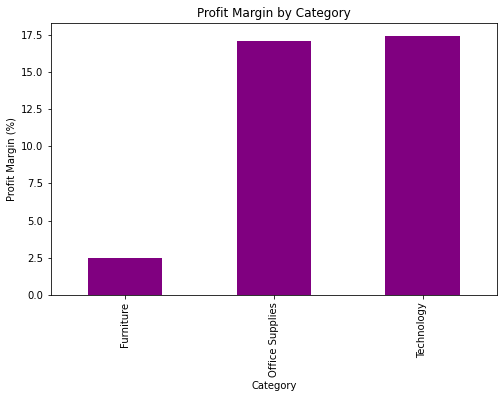

In [51]:
#2️⃣ رسم Profit Margin لكل فئة
category_profit_margin.plot(kind="bar", color='purple', figsize=(8,5), title="Profit Margin by Category")
plt.ylabel("Profit Margin (%)")
plt.show()

In [52]:
# 3️⃣ تحليل متقدم: Top Sub-Category حسب الربح والمبيعات معًا
subcat_summary = df.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Profit", ascending=False)
subcat_summary

,Sales,Profit
Sub-Category,,
Copiers,149528.0300,55617.8249
Phones,330007.0540,44515.7306
Accessories,167380.3180,41936.6357
Paper,78479.2060,34053.5693
Binders,203412.7330,30221.7633
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Appliances,107532.1610,18138.0054
Furnishings,91705.1640,13059.1436


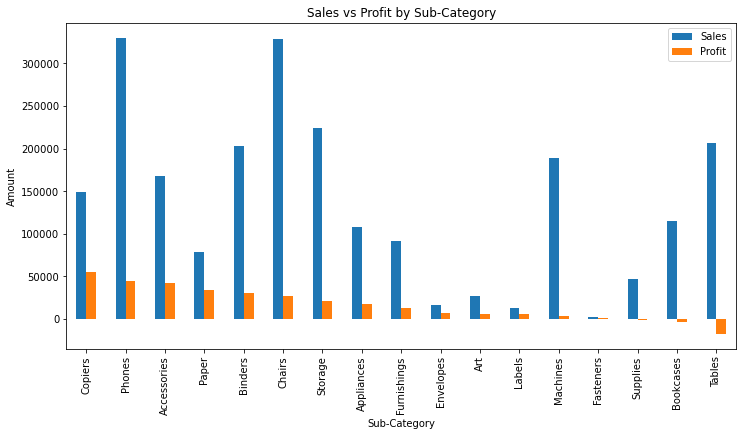

In [53]:
subcat_summary.plot(kind="bar", figsize=(12,6), title="Sales vs Profit by Sub-Category")
plt.ylabel("Amount")
plt.show()

In [54]:
# 4️⃣ لمسة نهائية: تحليل المبيعات حسب Region
region_sales = df.groupby("Region")["Sales"].sum()
region_profit = df.groupby("Region")["Profit"].sum()

region_summary = pd.DataFrame({"Sales": region_sales, "Profit": region_profit})
region_summary

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


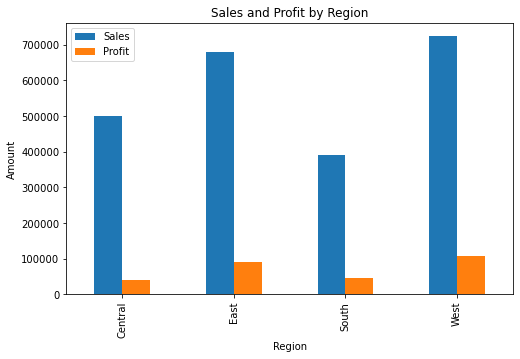

In [55]:
region_summary.plot(kind="bar", figsize=(8,5), title="Sales and Profit by Region")
plt.ylabel("Amount")
plt.show()